# FEMA National Flood Insurance Claims EDA

Dataset: `data/fema/FEMA_National_Flood_Insurance_Claims.csv`

This notebook performs exploratory data analysis for structure, completeness, date coverage, geographic coverage, and high-signal distributions. Run cells from top to bottom after installing the project dependencies.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent.parent

import duckdb

DATA_PATH = ROOT / "data" / "fema" / "FEMA_National_Flood_Insurance_Claims.csv"
csv_path = DATA_PATH.as_posix()
con = duckdb.connect()
con.execute("PRAGMA threads=4")
csv_rel = f"read_csv_auto('{csv_path}', sample_size=200000, ignore_errors=true)"
DATA_PATH

WindowsPath('C:/Users/kenny/Data Science Projects/quoll-intelligence/data/fema/FEMA_National_Flood_Insurance_Claims.csv')

## Schema And Scale

In [2]:
schema = con.execute(f"DESCRIBE SELECT * FROM {csv_rel}").df()
display(schema)
row_count = con.execute(f"SELECT count(*) AS rows FROM {csv_rel}").df()
row_count

,column_name,column_type,null,key,default,extra
0,column00,BIGINT,YES,None,None,None
1,agricultureStructureIndicator,BOOLEAN,YES,None,None,None
2,asOfDate,TIMESTAMP WITH TIME ZONE,YES,None,None,None
3,basementEnclosureCrawlspaceType,DOUBLE,YES,None,None,None
4,policyCount,BIGINT,YES,None,None,None
5,crsClassificationCode,DOUBLE,YES,None,None,None
6,dateOfLoss,DATE,YES,None,None,None
7,elevatedBuildingIndicator,BOOLEAN,YES,None,None,None
8,elevationCertificateIndicator,VARCHAR,YES,None,None,None
9,elevationDifference,DOUBLE,YES,None,None,None


,rows
0,2719462


In [3]:
sample = con.execute(f"SELECT * FROM {csv_rel} USING SAMPLE 100000 ROWS").df()
display(sample.head())
display(sample.dtypes.to_frame("dtype"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column00,agricultureStructureIndicator,asOfDate,basementEnclosureCrawlspaceType,policyCount,crsClassificationCode,dateOfLoss,elevatedBuildingIndicator,elevationCertificateIndicator,elevationDifference,baseFloodElevation,ratedFloodZone,houseWorship,locationOfContents,lowestAdjacentGrade,lowestFloorElevation,numberOfFloorsInTheInsuredBuilding,nonProfitIndicator,obstructionType,occupancyType,originalConstructionDate,originalNBDate,amountPaidOnBuildingClaim,amountPaidOnContentsClaim,amountPaidOnIncreasedCostOfComplianceClaim,postFIRMConstructionIndicator,rateMethod,smallBusinessIndicatorBuilding,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,yearOfLoss,primaryResidenceIndicator,buildingDamageAmount,buildingDeductibleCode,netBuildingPaymentAmount,buildingPropertyValue,causeOfDamage,condominiumCoverageTypeCode,contentsDamageAmount,contentsDeductibleCode,netContentsPaymentAmount,contentsPropertyValue,disasterAssistanceCoverageRequired,eventDesignationNumber,ficoNumber,floodCharacteristicsIndicator,floodWaterDuration,floodproofedIndicator,floodEvent,iccCoverage,netIccPaymentAmount,nfipRatedCommunityNumber,nfipCommunityNumberCurrent,nfipCommunityName,nonPaymentReasonContents,nonPaymentReasonBuilding,numberOfUnits,buildingReplacementCost,contentsReplacementCost,replacementCostBasis,stateOwnedIndicator,waterDepth,floodZoneCurrent,buildingDescriptionCode,rentalPropertyIndicator,state,reportedCity,reportedZipCode,countyCode,censusTract,censusBlockGroupFips,latitude,longitude,id
0,1138626,False,2026-01-11 17:00:00-07:00,NaN,1,6.0,2017-08-26,False,None,NaN,NaN,X,False,3.0,NaN,NaN,1.0,False,NaN,1.0,2003-01-01,2011-06-22,63978.78,10505.11,0.0,True,7,False,150000.0,60000.0,2017,True,65228.0,F,63978.78,203294.0,2,N,11755.0,F,10505.11,48000.0,0.0,None,682.0,NaN,0.0,False,Hurricane Harvey,30000.0,0.0,485488,485488,"LEAGUE CITY, CITY OF",None,None,1.0,243308.0,0.0,A,False,1.0,X,1.0,False,TX,Currently Unavailable,77539,48167,48167720600,481677206002,29.5,-95.1,b'\xb5\xae\xce\x13\xd4]L\x15\x97\x8a\x03\\\xd0...
1,2271641,False,2026-01-11 17:00:00-07:00,NaN,1,NaN,2008-08-31,False,2,NaN,NaN,X,False,NaN,NaN,NaN,3.0,False,NaN,4.0,1992-10-01,2004-01-11,NaN,NaN,NaN,True,1,False,275000.0,0.0,2008,False,NaN,5,0.00,NaN,4,N,NaN,0,0.00,NaN,0.0,None,221.0,NaN,0.0,False,Hurricane Gustav,30000.0,0.0,015007,None,None,None,06,1.0,NaN,NaN,A,False,0.0,None,NaN,False,AL,Currently Unavailable,36602,01097,01097000200,010970002001,30.7,-88.0,b'\x92\x81\x8a\xb6\xfcYKc\xb5t\x82c\x0c\xbc\x05h'
2,1445457,False,2026-01-11 17:00:00-07:00,NaN,1,NaN,1984-10-25,False,None,NaN,NaN,C,False,3.0,NaN,NaN,1.0,False,10.0,1.0,1979-05-01,1984-02-04,348.56,0.00,0.0,True,1,False,157300.0,60000.0,1984,False,1054.0,0,348.56,121000.0,2,N,NaN,0,0.00,NaN,0.0,None,523.0,NaN,0.0,False,Flooding,NaN,0.0,480287,None,None,97,None,1.0,0.0,NaN,A,False,0.0,None,NaN,False,TX,Currently Unavailable,77449,48201,48201542500,482015425001,29.8,-95.8,"b',\xcdt\xc2\x19\xc9D_\xaae\xd8\xd789\x11\xb1'"
3,1917971,False,2026-01-11 17:00:00-07:00,NaN,1,NaN,2016-10-08,True,3,0.0,10.0,A07,False,3.0,10.0,10.0,1.0,False,10.0,1.0,1990-07-01,2002-03-08,1507.90,402.46,0.0,True,1,False,250000.0,100000.0,2016,True,2480.0,F,1507.90,485742.0,1,N,1652.0,F,402.46,0.0,0.0,None,357.0,NaN,0.0,False,Hurricane Matthew,30000.0,0.0,450250,None,None,None,None,1.0,578264.0,0.0,R,False,2.0,None,1.0,False,SC,Currently Unavailable,29926,45013,45013010600,450130106001,32.3,-80.7,b'\xc3&\xb2\xf3\x10#O(\x96nx>U|\xfaK'
4,2187655,False,2026-01-11 17:00:00-07:00,2.0,1,NaN,2016-10-08,False,None,NaN,NaN,A07,False,2.0,NaN,NaN,3.0,False,NaN,1.0,1945-10-10,2014-08-31,5943.46,0.00,0.0,False,1,False,157000.0,57400.0,2016,False,7943.0,2,5943.46,148580.0,4,N,NaN,2,0.00,NaN,0.0,None,357.0,NaN,0.0,False,Hurricane Matthew,30000.0,0.0,455412,None,None,20,None,1.0,209267.0,NaN,A,False,2.0,None,1.0,False,SC,Currently Unavailable,29403,45019,45019000600,450190006001,32.8,-79.9,b'P\xc8\xa4\xf0\xad:FX\x85{B\xdaJ\x00\xee\xf2'


,dtype
column00,int64
agricultureStructureIndicator,bool
asOfDate,"datetime64[us, America/Denver]"
basementEnclosureCrawlspaceType,float64
policyCount,int64
crsClassificationCode,float64
dateOfLoss,datetime64[us]
elevatedBuildingIndicator,bool
elevationCertificateIndicator,object
elevationDifference,float64


## Completeness In Sample

In [4]:
def missing_summary(frame: pd.DataFrame) -> pd.DataFrame:
    missing = frame.isna().sum()
    unique_values = []
    for col in frame.columns:
        try:
            unique_values.append(frame[col].nunique(dropna=True))
        except TypeError:
            unique_values.append(np.nan)
    return (
        pd.DataFrame({
            "missing_count": missing,
            "missing_pct": missing / len(frame) * 100,
            "dtype": frame.dtypes.astype(str),
            "unique_values": unique_values,
        })
        .sort_values("missing_pct", ascending=False)
    )


missing_summary(sample).head(35)

,missing_count,missing_pct,dtype,unique_values
floodCharacteristicsIndicator,98530,98.530,float64,5
crsClassificationCode,94660,94.660,float64,8
eventDesignationNumber,93184,93.184,object,53
lowestAdjacentGrade,81100,81.100,float64,2410
nonPaymentReasonBuilding,77855,77.855,object,23
elevationCertificateIndicator,77752,77.752,object,9
lowestFloorElevation,76422,76.422,float64,2694
baseFloodElevation,75753,75.753,float64,2155
elevationDifference,73087,73.087,float64,84
floodZoneCurrent,71588,71.588,object,49


## Claim Amounts

In [5]:
amount_cols = [
    "amountPaidOnBuildingClaim",
    "amountPaidOnContentsClaim",
    "amountPaidOnIncreasedCostOfComplianceClaim",
    "netBuildingPaymentAmount",
    "netContentsPaymentAmount",
    "netIccPaymentAmount",
    "buildingDamageAmount",
    "contentsDamageAmount",
]
available_amount_cols = [c for c in amount_cols if c in sample.columns]
sample[available_amount_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
amountPaidOnBuildingClaim,79081.0,33733.479927,75259.193550,-33892.96,10162.11,39758.42,94612.160,140000.0000,250000.0000,9.100033e+06
amountPaidOnContentsClaim,79081.0,7331.431466,22303.018760,-20000.00,0.00,5000.00,21009.120,39036.9400,100000.0000,5.000000e+05
amountPaidOnIncreasedCostOfComplianceClaim,79081.0,440.494931,3412.977207,-6450.00,0.00,0.00,0.000,0.0000,30000.0000,3.925000e+04
netBuildingPaymentAmount,100000.0,26646.171146,68286.886840,-33892.96,5051.85,27216.10,80000.000,123362.7165,250000.0000,9.100033e+06
netContentsPaymentAmount,100000.0,5778.627487,20046.090920,-20000.00,0.00,2419.58,15929.685,31573.2450,87877.1705,5.000000e+05
netIccPaymentAmount,100000.0,347.450633,3036.525514,-6450.00,0.00,0.00,0.000,0.0000,20000.0000,3.000000e+04
buildingDamageAmount,78124.0,39871.035456,809827.637609,0.00,11910.00,43144.25,100030.200,145445.7000,272336.4300,2.250000e+08
contentsDamageAmount,42049.0,18569.437442,91780.862550,0.00,5739.00,18923.00,45079.600,68199.0000,133666.1200,9.746047e+06


,yearOfLoss,claims,total_paid,avg_paid
29,2007,28360,6.141358e+08,21654.998423
30,2008,96968,3.491288e+09,36004.535568
31,2009,37734,7.801476e+08,20674.924547
32,2010,37818,7.738179e+08,20461.629069
33,2011,96466,2.431706e+09,25207.909213
34,2012,175804,9.740853e+09,55407.458588
35,2013,24062,4.934869e+08,20508.974411
36,2014,18772,3.817952e+08,20338.548584
37,2015,34581,1.045464e+09,30232.327584
38,2016,85497,4.468919e+09,52269.896186


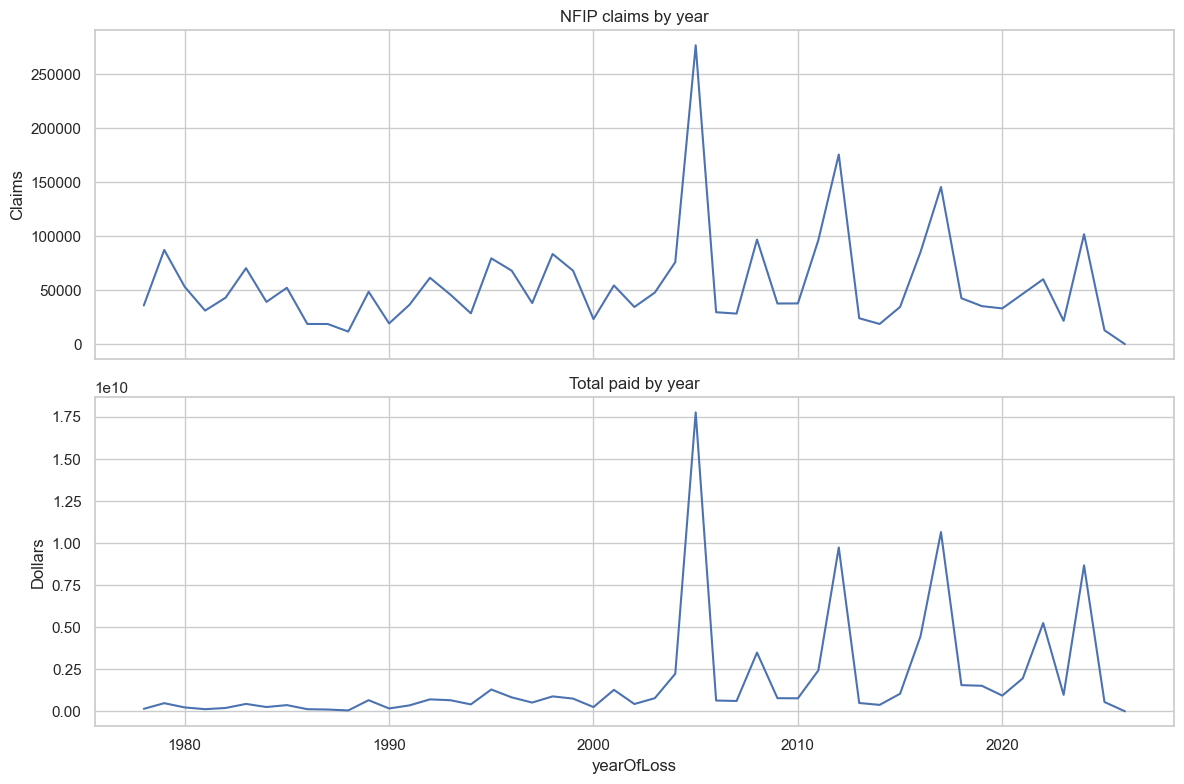

In [6]:
claim_expr = "coalesce(amountPaidOnBuildingClaim, 0) + coalesce(amountPaidOnContentsClaim, 0) + coalesce(amountPaidOnIncreasedCostOfComplianceClaim, 0)"
annual_claims = con.execute(f"""
    SELECT
        yearOfLoss,
        count(*) AS claims,
        sum({claim_expr}) AS total_paid,
        avg({claim_expr}) AS avg_paid
    FROM {csv_rel}
    WHERE yearOfLoss IS NOT NULL
    GROUP BY yearOfLoss
    ORDER BY yearOfLoss
""").df()
display(annual_claims.tail(20))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
annual_claims.plot(x="yearOfLoss", y="claims", ax=axes[0], legend=False, title="NFIP claims by year")
annual_claims.plot(x="yearOfLoss", y="total_paid", ax=axes[1], legend=False, title="Total paid by year")
axes[0].set_ylabel("Claims")
axes[1].set_ylabel("Dollars")
plt.tight_layout()
plt.show()

## Geography

,state,claims,total_paid,avg_paid
0,LA,484864,2.098254e+10,43275.107011
1,FL,448227,1.922285e+10,42886.413927
2,TX,393534,1.739762e+10,44208.695046
3,NJ,202121,6.508419e+09,32200.605214
4,NY,175144,5.744462e+09,32798.510282
5,MS,64223,3.126104e+09,48675.772152
6,NC,109455,2.294807e+09,20965.759327
7,PA,76881,1.441306e+09,18747.227996
8,AL,44857,1.195811e+09,26658.280850
9,SC,49593,1.038636e+09,20943.204974


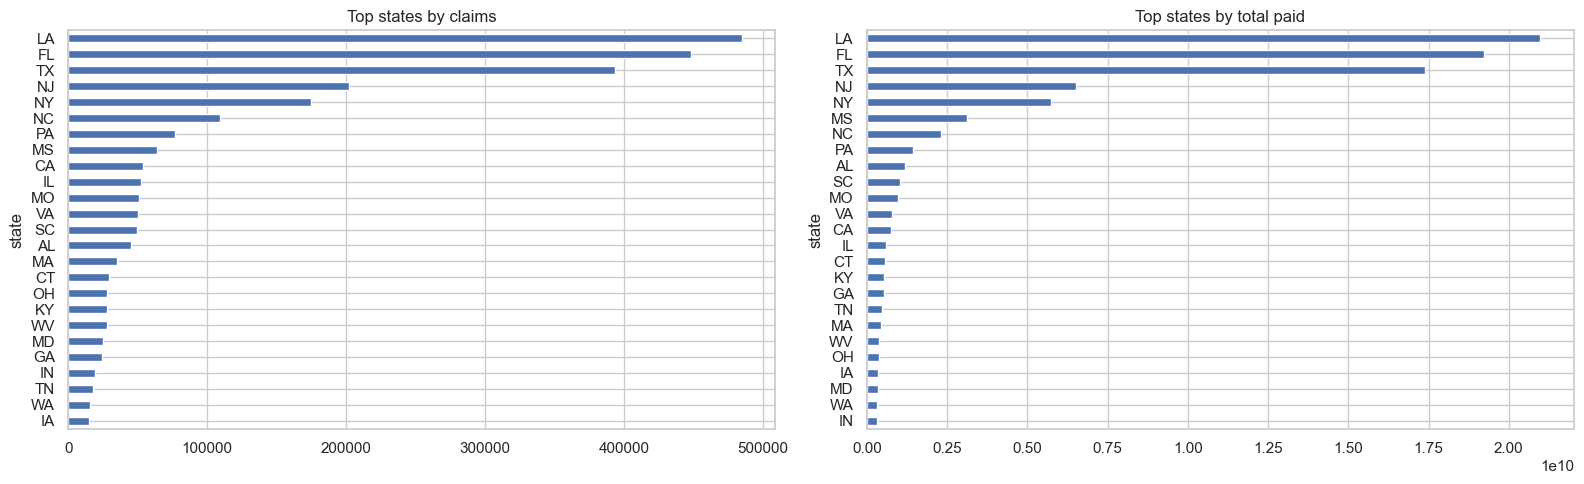

In [7]:
state_summary = con.execute(f"""
    SELECT
        state,
        count(*) AS claims,
        sum({claim_expr}) AS total_paid,
        avg({claim_expr}) AS avg_paid
    FROM {csv_rel}
    WHERE state IS NOT NULL
    GROUP BY state
    ORDER BY total_paid DESC
    LIMIT 25
""").df()
display(state_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
state_summary.sort_values("claims").plot(x="state", y="claims", kind="barh", ax=axes[0], legend=False, title="Top states by claims")
state_summary.sort_values("total_paid").plot(x="state", y="total_paid", kind="barh", ax=axes[1], legend=False, title="Top states by total paid")
plt.tight_layout()
plt.show()

In [8]:
con.execute(f"""
    SELECT
        state,
        reportedCity,
        count(*) AS claims,
        sum({claim_expr}) AS total_paid
    FROM {csv_rel}
    WHERE state IS NOT NULL AND reportedCity IS NOT NULL
    GROUP BY state, reportedCity
    ORDER BY total_paid DESC
    LIMIT 30
""").df()

,state,reportedCity,claims,total_paid
0,LA,Currently Unavailable,484864,2.098254e+10
1,FL,Currently Unavailable,448227,1.922285e+10
2,TX,Currently Unavailable,393534,1.739762e+10
3,NJ,Currently Unavailable,202121,6.508419e+09
4,NY,Currently Unavailable,175144,5.744462e+09
5,MS,Currently Unavailable,64223,3.126104e+09
6,NC,Currently Unavailable,109455,2.294807e+09
7,PA,Currently Unavailable,76881,1.441306e+09
8,AL,Currently Unavailable,44857,1.195811e+09
9,SC,Currently Unavailable,49593,1.038636e+09


## Flood Zone And Building Characteristics

In [9]:
for col in ["floodZoneCurrent", "ratedFloodZone", "occupancyType", "causeOfDamage", "primaryResidenceIndicator"]:
    if col in sample.columns:
        display(sample[col].value_counts(dropna=False).head(20).to_frame("sample_count"))

,sample_count
floodZoneCurrent,
None,71588
AE,17791
X,6120
VE,1097
A,970
C,352
B,319
AHB,289
AH,216


,sample_count
ratedFloodZone,
AE,34677
X,14852
A,7334
C,6129
None,5193
B,4129
A04,1929
A01,1851
VE,1813


,sample_count
occupancyType,
1.0,65760
11.0,15306
4.0,6271
2.0,4855
3.0,2930
18.0,1346
6.0,870
15.0,867
12.0,704


,sample_count
causeOfDamage,
4,44264
1,25624
2,19943
0,7449
None,1329
B,582
3,481
D,210
9,45


,sample_count
primaryResidenceIndicator,
False,50960
True,49040
